In [9]:
# ========================= ONE-CELL: 6-CLASS (LIAR2) Train + Evaluate + Save + Inference =========================
!pip -q install -U \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "datasets>=4.0.0" \
  "transformers>=5.1.0" \
  "accelerate>=0.33.0" \
  "evaluate>=0.4.2" \
  "scikit-learn>=1.4.0"

import os, re, platform
import numpy as np
import pandas as pd
import torch

import datasets, transformers
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
    pipeline,
)

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Platform:", platform.platform())
print("Pandas:", pd.__version__)
print("Datasets:", datasets.__version__)
print("Transformers:", transformers.__version__)

# ------------------------- 0) Repro -------------------------
set_seed(42)

# ------------------------- 1) Load dataset -------------------------
ds = load_dataset("chengxuphd/liar2")  # train/validation/test
print(ds)

# ------------------------- 2) 6-class label names (standard LIAR order) -------------------------
# The original LIAR paper uses 6 fine-grained labels: pants-fire, false, barely-true, half-true, mostly-true, true.
# We'll assume LIAR2 uses the same 0..5 ordering (as commonly used in LIAR-style releases).
id2label = {
    0: "pants-fire",
    1: "false",
    2: "barely-true",
    3: "half-true",
    4: "mostly-true",
    5: "true",
}
label2id = {v: k for k, v in id2label.items()}

# ------------------------- 3) Build input text (stronger than statement-only, but still stable) -------------------------
USE_JUSTIFICATION = True   # uses evidence-like field (often improves)
USE_META = True            # adds small metadata; can help

def clean_text(x):
    x = "" if x is None else str(x)
    x = x.replace("\r", " ").replace("\n", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def build_text(ex):
    statement = clean_text(ex.get("statement"))
    justification = clean_text(ex.get("justification"))
    subject = clean_text(ex.get("subject"))
    speaker = clean_text(ex.get("speaker"))
    context = clean_text(ex.get("context"))

    parts = [f"CLAIM: {statement}"]
    if USE_JUSTIFICATION and justification:
        parts.append(f"JUSTIFICATION: {justification}")
    if USE_META:
        if subject: parts.append(f"SUBJECT: {subject}")
        if speaker: parts.append(f"SPEAKER: {speaker}")
        if context: parts.append(f"CONTEXT: {context}")

    y = int(ex["label"])  # 0..5
    return {"text": " [SEP] ".join(parts), "labels": y}

ds2 = ds.map(build_text)

# ------------------------- 4) Tokenize -------------------------
# Choose a stable backbone to avoid LayerNorm gamma/beta checkpoint quirks you saw with DeBERTa in your environment.
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

MAX_LEN = 256  # safe on T4; raise to 320 if you have RAM/GPU headroom

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

ds_tok = ds2.map(tok, batched=True)

# Keep only model inputs
KEEP = {"input_ids", "attention_mask", "labels"}
for split in ["train", "validation", "test"]:
    drop = [c for c in ds_tok[split].column_names if c not in KEEP]
    if drop:
        ds_tok[split] = ds_tok[split].remove_columns(drop)

# Sanity checks
label_set = set(ds_tok["train"]["labels"])
assert label_set.issubset(set(range(6))), f"Bad labels found: {sorted(label_set)}"
print("Final columns:", ds_tok["train"].column_names, "| Label set:", sorted(label_set))
print("Sizes:", {k: len(ds_tok[k]) for k in ["train","validation","test"]})

# ------------------------- 5) Metrics (macro-F1 is the key for 6-class) -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    # per-class precision/recall/f1 (macro table)
    p_c, r_c, f1_c, _ = precision_recall_fscore_support(labels, preds, labels=list(range(6)), zero_division=0)
    metrics = {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }
    # Add compact per-class f1
    for i in range(6):
        metrics[f"f1_{id2label[i]}"] = float(f1_c[i])
    return metrics

# ------------------------- 6) Model -------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=6)
model.config.id2label = id2label
model.config.label2id = label2id

# Optional speed/memory helpers (safe)
model.gradient_checkpointing_enable()

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

# ------------------------- 7) TrainingArguments (Transformers v5 uses eval_strategy) -------------------------
# IMPORTANT: We set fp16=False to avoid "Attempting to unscale FP16 gradients" issues you saw earlier.
per_device_train_bs = 16
grad_accum = 2  # effective batch size = 32
epochs = 3

steps_per_epoch = int(np.ceil(len(ds_tok["train"]) / per_device_train_bs / grad_accum))
total_steps = steps_per_epoch * epochs
warmup_steps = int(0.06 * total_steps)

args = TrainingArguments(
    output_dir="liar2_roberta_base_6class",
    eval_strategy="steps",
    eval_steps=250,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=False,  # <-- stability (prevents AMP unscale errors)
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type="linear",

    per_device_train_batch_size=per_device_train_bs,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=grad_accum,

    num_train_epochs=epochs,
    logging_steps=50,

    report_to="none",
    dataloader_num_workers=2,
    seed=42,
    data_seed=42,

    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ------------------------- 8) Train + Evaluate -------------------------
trainer.train()

valid_metrics = trainer.evaluate(ds_tok["validation"])
test_metrics  = trainer.evaluate(ds_tok["test"])
print("\nVALID:", valid_metrics)
print("TEST :", test_metrics)

# ------------------------- 9) Confusion matrix + per-class report (on validation) -------------------------
pred_valid = trainer.predict(ds_tok["validation"])
valid_preds = np.argmax(pred_valid.predictions, axis=-1)
valid_labels = pred_valid.label_ids

print("\nConfusion matrix (validation) rows=true, cols=pred:")
print(confusion_matrix(valid_labels, valid_preds, labels=list(range(6))))

print("\nClassification report (validation):")
print(classification_report(valid_labels, valid_preds, target_names=[id2label[i] for i in range(6)], zero_division=0))

# ------------------------- 10) Save + Inference -------------------------
SAVE_DIR = "liar2_roberta_base_6class_final"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

clf = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,  # v5 way to return all class scores
)

sample = '90 percent of Americans "support universal background checks" for gun purchases.'
print("\nSample:", sample)
print("All scores:", clf(sample))


Torch: 2.9.0+cu126
CUDA: True | GPU: Tesla T4
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Pandas: 2.2.2
Datasets: 4.5.0
Transformers: 5.1.0
DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 18369
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2297
    })
    test: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_coun

Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


VALID: {'eval_loss': 0.7818741202354431, 'eval_accuracy': 0.7239878101872007, 'eval_f1_macro': 0.7186929744365719, 'eval_f1_weighted': 0.7227503674937121, 'eval_f1_pants-fire': 0.8126159554730983, 'eval_f1_false': 0.7710843373493976, 'eval_f1_barely-true': 0.610062893081761, 'eval_f1_half-true': 0.6909547738693468, 'eval_f1_mostly-true': 0.6987270155586988, 'eval_f1_true': 0.7287128712871287, 'eval_runtime': 33.3291, 'eval_samples_per_second': 68.919, 'eval_steps_per_second': 1.08, 'epoch': 3.0}
TEST : {'eval_loss': 0.7266015410423279, 'eval_accuracy': 0.7356271777003485, 'eval_f1_macro': 0.7320179157842263, 'eval_f1_weighted': 0.7344929470618765, 'eval_f1_pants-fire': 0.8245931283905967, 'eval_f1_false': 0.7810734463276836, 'eval_f1_barely-true': 0.6327160493827161, 'eval_f1_half-true': 0.6719367588932806, 'eval_f1_mostly-true': 0.7165021156558533, 'eval_f1_true': 0.7652859960552268, 'eval_runtime': 31.5652, 'eval_samples_per_second': 72.738, 'eval_steps_per_second': 1.14, 'epoch': 3

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sample: 90 percent of Americans "support universal background checks" for gun purchases.
All scores: [[{'label': 'true', 'score': 0.8476936221122742}, {'label': 'mostly-true', 'score': 0.08650768548250198}, {'label': 'false', 'score': 0.02359846793115139}, {'label': 'half-true', 'score': 0.021251892670989037}, {'label': 'barely-true', 'score': 0.01265749242156744}, {'label': 'pants-fire', 'score': 0.008290874771773815}]]


In [11]:
# ========================= ONE-CELL: LIAR2 6-CLASS FORENSICS (NO RETRAIN) =========================
# Fixes the "too many dimensions 'str'" error by ensuring prediction batches never include string columns.
# Uses Trainer.predict() which safely removes unused columns when building dataloaders. (HF docs)
# Outputs forensic CSVs you can use in your paper.

!pip -q install -U \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "datasets>=4.0.0" \
  "transformers>=5.1.0" \
  "accelerate>=0.33.0" \
  "scikit-learn>=1.4.0"

import os, re, platform, json, math
import numpy as np
import pandas as pd
import torch

import datasets, transformers
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Platform:", platform.platform())
print("Pandas:", pd.__version__)
print("Datasets:", datasets.__version__)
print("Transformers:", transformers.__version__)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------- 1) Paths -------------------------
# Change this if you saved under a different folder.
MODEL_DIR = "liar2_roberta_base_6class_final"   # saved by trainer.save_model(...)
# If you want to load from your training output directory instead, use:
# MODEL_DIR = "liar2_roberta_base_6class"  # must contain model files

assert os.path.isdir(MODEL_DIR), f"MODEL_DIR not found: {MODEL_DIR}. Check your saved folder name."

# ------------------------- 2) Dataset + label mapping -------------------------
ds = load_dataset("chengxuphd/liar2")

id2label = {
    0: "pants-fire",
    1: "false",
    2: "barely-true",
    3: "half-true",
    4: "mostly-true",
    5: "true",
}
label2id = {v: k for k, v in id2label.items()}
LABEL_NAMES = [id2label[i] for i in range(6)]

# ------------------------- 3) Rebuild the SAME text field as training -------------------------
USE_JUSTIFICATION = True
USE_META = True

def clean_text(x):
    x = "" if x is None else str(x)
    x = x.replace("\r", " ").replace("\n", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def build_text(ex):
    statement = clean_text(ex.get("statement"))
    justification = clean_text(ex.get("justification"))
    subject = clean_text(ex.get("subject"))
    speaker = clean_text(ex.get("speaker"))
    context = clean_text(ex.get("context"))

    parts = [f"CLAIM: {statement}"]
    if USE_JUSTIFICATION and justification:
        parts.append(f"JUSTIFICATION: {justification}")
    if USE_META:
        if subject: parts.append(f"SUBJECT: {subject}")
        if speaker: parts.append(f"SPEAKER: {speaker}")
        if context: parts.append(f"CONTEXT: {context}")

    y = int(ex["label"])  # 0..5
    return {"text": " [SEP] ".join(parts), "labels": y}

ds2 = ds.map(build_text)

# ------------------------- 4) Load tokenizer/model from saved directory -------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)

# Ensure label maps exist in config (nice for reporting)
model.config.id2label = id2label
model.config.label2id = label2id

MAX_LEN = 256

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

ds_tok = ds2.map(tok, batched=True)

# IMPORTANT:
# Keep text in ds_tok for exporting examples,
# BUT we will create a "model-only" view for Trainer.predict() so it never sees strings.
KEEP_MODEL = {"input_ids", "attention_mask", "labels"}
ds_model = {}
for split in ["train", "validation", "test"]:
    drop = [c for c in ds_tok[split].column_names if c not in KEEP_MODEL]
    ds_model[split] = ds_tok[split].remove_columns(drop)

print("Tokenized columns (full):", ds_tok["validation"].column_names)
print("Tokenized columns (model-only):", ds_model["validation"].column_names)

# ------------------------- 5) Metrics helpers -------------------------
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def compute_metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    p_c, r_c, f1_c, s_c = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(6)), zero_division=0
    )
    per_class = pd.DataFrame({
        "class_id": list(range(6)),
        "label": [id2label[i] for i in range(6)],
        "support": s_c.astype(int),
        "precision": p_c,
        "recall": r_c,
        "f1": f1_c,
    })
    return acc, f1_macro, f1_weighted, per_class

# ------------------------- 6) Predict safely with Trainer.predict() -------------------------
# Using Trainer avoids the collator trying to tensorize 'text' because ds_model only has numeric columns.
args = TrainingArguments(
    output_dir="forensics_tmp",
    per_device_eval_batch_size=96,
    dataloader_num_workers=2,
    report_to="none",
    fp16=False,
    remove_unused_columns=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

trainer = Trainer(
    model=model,
    args=args,
    data_collator=data_collator,
)

def predict_split(split_name):
    pred = trainer.predict(ds_model[split_name])
    logits = pred.predictions
    y_true = pred.label_ids
    probs = softmax(logits, axis=-1)
    y_pred = np.argmax(probs, axis=-1)
    conf = probs[np.arange(len(y_pred)), y_pred]
    return logits, probs, y_true, y_pred, conf

val_logits, val_probs, val_y, val_pred, val_conf = predict_split("validation")
test_logits, test_probs, test_y, test_pred, test_conf = predict_split("test")

# ------------------------- 7) Core reports (tables) -------------------------
val_acc, val_f1m, val_f1w, val_per_class = compute_metrics_from_preds(val_y, val_pred)
test_acc, test_f1m, test_f1w, test_per_class = compute_metrics_from_preds(test_y, test_pred)

print("\n=== VALIDATION SUMMARY ===")
print({"accuracy": val_acc, "f1_macro": val_f1m, "f1_weighted": val_f1w})
print("\n=== TEST SUMMARY ===")
print({"accuracy": test_acc, "f1_macro": test_f1m, "f1_weighted": test_f1w})

cm_val = confusion_matrix(val_y, val_pred, labels=list(range(6)))
cm_test = confusion_matrix(test_y, test_pred, labels=list(range(6)))

print("\nConfusion matrix (validation) rows=true, cols=pred:\n", cm_val)

print("\nClassification report (validation):")
print(classification_report(val_y, val_pred, target_names=LABEL_NAMES, zero_division=0))

# ------------------------- 8) Forensic deep-dive tables -------------------------
# Attach texts for example mining WITHOUT letting the model see them in batching.
val_texts = ds_tok["validation"]["text"]
test_texts = ds_tok["test"]["text"]

def make_examples_df(split_name, y_true, y_pred, conf, probs, texts):
    df = pd.DataFrame({
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "true_label": [id2label[int(i)] for i in y_true],
        "pred_label": [id2label[int(i)] for i in y_pred],
        "confidence": conf,
        "text": list(texts),
    })
    # add per-class probs
    for i, name in enumerate(LABEL_NAMES):
        df[f"p_{name}"] = probs[:, i]
    df["correct"] = (df["y_true"] == df["y_pred"])
    return df

df_val = make_examples_df("validation", val_y, val_pred, val_conf, val_probs, val_texts)
df_test = make_examples_df("test", test_y, test_pred, test_conf, test_probs, test_texts)

# Top confusion pairs (validation)
cm_pairs = []
for i in range(6):
    for j in range(6):
        if i != j and cm_val[i, j] > 0:
            cm_pairs.append({
                "true": id2label[i],
                "pred": id2label[j],
                "count": int(cm_val[i, j])
            })
df_confusions = pd.DataFrame(cm_pairs).sort_values("count", ascending=False).reset_index(drop=True)

# Hard examples:
# 1) High-confidence wrong predictions
df_hcw = df_val[~df_val["correct"]].sort_values("confidence", ascending=False).head(25)

# 2) Low-confidence correct predictions (borderline)
df_lcc = df_val[df_val["correct"]].sort_values("confidence", ascending=True).head(25)

# Per-class confidence stats (validation)
df_conf_stats = (
    df_val.groupby("true_label")
    .agg(
        support=("true_label", "size"),
        acc=("correct", "mean"),
        avg_conf=("confidence", "mean"),
        med_conf=("confidence", "median"),
    )
    .reset_index()
    .sort_values("support", ascending=False)
)

# ------------------------- 9) Save everything as CSV (paper-ready artifacts) -------------------------
OUTDIR = "forensics_outputs"
os.makedirs(OUTDIR, exist_ok=True)

val_per_class.to_csv(os.path.join(OUTDIR, "validation_per_class_metrics.csv"), index=False)
test_per_class.to_csv(os.path.join(OUTDIR, "test_per_class_metrics.csv"), index=False)

pd.DataFrame(cm_val, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(os.path.join(OUTDIR, "confusion_matrix_validation.csv"))
pd.DataFrame(cm_test, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(os.path.join(OUTDIR, "confusion_matrix_test.csv"))

df_confusions.to_csv(os.path.join(OUTDIR, "top_confusion_pairs_validation.csv"), index=False)

df_hcw.to_csv(os.path.join(OUTDIR, "high_confidence_wrong_validation.csv"), index=False)
df_lcc.to_csv(os.path.join(OUTDIR, "low_confidence_correct_validation.csv"), index=False)

df_conf_stats.to_csv(os.path.join(OUTDIR, "confidence_stats_by_true_class_validation.csv"), index=False)

# Optional: a compact summary JSON you can paste into your paper appendix
summary = {
    "model_dir": MODEL_DIR,
    "max_len": MAX_LEN,
    "validation": {"accuracy": float(val_acc), "f1_macro": float(val_f1m), "f1_weighted": float(val_f1w)},
    "test": {"accuracy": float(test_acc), "f1_macro": float(test_f1m), "f1_weighted": float(test_f1w)},
}
with open(os.path.join(OUTDIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Forensics saved to: {OUTDIR}/")
print("Files:")
for fn in sorted(os.listdir(OUTDIR)):
    print(" -", fn)

# ------------------------- 10) Quick insight prints (top confusions + worst classes) -------------------------
print("\n=== Top confusion pairs (validation) ===")
print(df_confusions.head(10))

print("\n=== Per-class confidence stats (validation) ===")
print(df_conf_stats)

print("\n=== 10 highest-confidence WRONG examples (validation) ===")
print(df_hcw[["true_label","pred_label","confidence","text"]].head(10))

print("\n=== 10 lowest-confidence CORRECT examples (validation) ===")
print(df_lcc[["true_label","pred_label","confidence","text"]].head(10))


Torch: 2.9.0+cu126
CUDA: True | GPU: Tesla T4
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Pandas: 2.2.2
Datasets: 4.5.0
Transformers: 5.1.0
Device: cuda


Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

Tokenized columns (full): ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification', 'text', 'labels', 'input_ids', 'attention_mask']
Tokenized columns (model-only): ['labels', 'input_ids', 'attention_mask']



=== VALIDATION SUMMARY ===
{'accuracy': 0.7239878101872007, 'f1_macro': 0.7186929744365719, 'f1_weighted': 0.7227503674937121}

=== TEST SUMMARY ===
{'accuracy': 0.7356271777003485, 'f1_macro': 0.7320179157842263, 'f1_weighted': 0.7344929470618765}

Confusion matrix (validation) rows=true, cols=pred:
 [[219  73   4   3   1   3]
 [ 16 544  42  26  11  22]
 [  1  81 194  70  12   3]
 [  0  21  24 275  46   5]
 [  0  13   8  45 247  30]
 [  0  18   3   6  47 184]]

Classification report (validation):
              precision    recall  f1-score   support

  pants-fire       0.93      0.72      0.81       303
       false       0.73      0.82      0.77       661
 barely-true       0.71      0.54      0.61       361
   half-true       0.65      0.74      0.69       371
 mostly-true       0.68      0.72      0.70       343
        true       0.74      0.71      0.73       258

    accuracy                           0.72      2297
   macro avg       0.74      0.71      0.72      2297
weighted

In [12]:
# ========================= ONE-CELL: Load Trained Model + Forensics (NO retrain) =========================
!pip -q install -U \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "datasets>=4.0.0" \
  "transformers>=5.1.0" \
  "accelerate>=0.33.0" \
  "scikit-learn>=1.4.0"

import os, re, json, platform
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# ------------------------- SETTINGS -------------------------
MODEL_DIR = "liar2_roberta_base_6class_final"  # <-- CHANGE to your saved model folder
OUT_DIR = "forensics_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Platform:", platform.platform())
print("Device:", DEVICE)

# ------------------------- Labels -------------------------
id2label = {
    0: "pants-fire",
    1: "false",
    2: "barely-true",
    3: "half-true",
    4: "mostly-true",
    5: "true",
}
label2id = {v: k for k, v in id2label.items()}
LABELS = list(range(6))
LABEL_NAMES = [id2label[i] for i in LABELS]

# ------------------------- Build text exactly like training -------------------------
USE_JUSTIFICATION = True
USE_META = True

def clean_text(x):
    x = "" if x is None else str(x)
    x = x.replace("\r", " ").replace("\n", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def build_text(ex):
    statement = clean_text(ex.get("statement"))
    justification = clean_text(ex.get("justification"))
    subject = clean_text(ex.get("subject"))
    speaker = clean_text(ex.get("speaker"))
    context = clean_text(ex.get("context"))

    parts = [f"CLAIM: {statement}"]
    if USE_JUSTIFICATION and justification:
        parts.append(f"JUSTIFICATION: {justification}")
    if USE_META:
        if subject: parts.append(f"SUBJECT: {subject}")
        if speaker: parts.append(f"SPEAKER: {speaker}")
        if context: parts.append(f"CONTEXT: {context}")

    return {"text": " [SEP] ".join(parts), "labels": int(ex["label"])}

# ------------------------- Load dataset -------------------------
ds = load_dataset("chengxuphd/liar2")
ds2 = ds.map(build_text)

# ------------------------- Load tokenizer + model -------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.config.id2label = id2label
model.config.label2id = label2id
model.to(DEVICE)
model.eval()

MAX_LEN = 256

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

ds_tok = ds2.map(tok, batched=True)

print("Tokenized columns (full):", ds_tok["validation"].column_names)

# IMPORTANT: Create a MODEL-ONLY view for dataloaders (NO 'text' strings in batches)
MODEL_COLS = ["input_ids", "attention_mask", "labels"]

def to_model_only(split):
    d = ds_tok[split].select_columns(["text"] + MODEL_COLS)  # keep text for indexing, but NOT for collator input
    # We'll separately create a tensor-only dataset for batching:
    d_model = d.remove_columns(["text"])
    d_model.set_format(type="torch", columns=MODEL_COLS)
    texts = d["text"]  # plain python list of strings
    return d_model, texts

val_model, val_texts = to_model_only("validation")
test_model, test_texts = to_model_only("test")

print("Tokenized columns (model-only):", val_model.column_names)

collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

@torch.no_grad()
def predict_split(dset_model, texts, batch_size=96):
    dl = DataLoader(dset_model, batch_size=batch_size, shuffle=False, collate_fn=collator)
    all_logits = []
    all_labels = []
    for batch in dl:
        labels = batch.pop("labels").cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch)
        logits = out.logits.detach().cpu().numpy()
        all_logits.append(logits)
        all_labels.append(labels)

    logits = np.concatenate(all_logits, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    y_pred = probs.argmax(axis=-1)
    conf = probs.max(axis=-1)
    return logits, probs, y_pred, conf, y_true, texts

# ------------------------- Run predictions -------------------------
val_logits, val_probs, val_pred, val_conf, val_y, val_txt = predict_split(val_model, val_texts, batch_size=96)
test_logits, test_probs, test_pred, test_conf, test_y, test_txt = predict_split(test_model, test_texts, batch_size=96)

# ------------------------- Summary metrics -------------------------
def summary_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted")),
    }

val_sum = summary_metrics(val_y, val_pred)
test_sum = summary_metrics(test_y, test_pred)

print("\n=== VALIDATION SUMMARY ===")
print(val_sum)
print("\n=== TEST SUMMARY ===")
print(test_sum)

with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:
    json.dump({"validation": val_sum, "test": test_sum}, f, indent=2)

# ------------------------- Confusion matrices -------------------------
cm_val = confusion_matrix(val_y, val_pred, labels=LABELS)
cm_test = confusion_matrix(test_y, test_pred, labels=LABELS)

pd.DataFrame(cm_val, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(os.path.join(OUT_DIR, "confusion_matrix_validation.csv"))
pd.DataFrame(cm_test, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(os.path.join(OUT_DIR, "confusion_matrix_test.csv"))

print("\nConfusion matrix (validation) rows=true, cols=pred:\n", cm_val)

# ------------------------- Per-class metrics -------------------------
def per_class_table(y_true, y_pred, split_name):
    p, r, f1, s = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)
    df = pd.DataFrame({
        "label_id": LABELS,
        "label": LABEL_NAMES,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": s,
    })
    df.to_csv(os.path.join(OUT_DIR, f"{split_name}_per_class_metrics.csv"), index=False)
    return df

val_pc = per_class_table(val_y, val_pred, "validation")
test_pc = per_class_table(test_y, test_pred, "test")

print("\nClassification report (validation):")
print(classification_report(val_y, val_pred, target_names=LABEL_NAMES, zero_division=0))

# ------------------------- Top confusion pairs -------------------------
def top_confusions(cm, topk=15):
    rows = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                rows.append((LABEL_NAMES[i], LABEL_NAMES[j], int(cm[i, j])))
    df = pd.DataFrame(rows, columns=["true", "pred", "count"]).sort_values("count", ascending=False).head(topk)
    return df

top_pairs = top_confusions(cm_val, topk=20)
top_pairs.to_csv(os.path.join(OUT_DIR, "top_confusion_pairs_validation.csv"), index=False)

print("\n=== Top confusion pairs (validation) ===")
print(top_pairs.head(10))

# ------------------------- Confidence diagnostics -------------------------
val_df = pd.DataFrame({
    "true_id": val_y,
    "pred_id": val_pred,
    "true_label": [id2label[i] for i in val_y],
    "pred_label": [id2label[i] for i in val_pred],
    "confidence": val_conf,
    "text": val_txt,
})
val_df["correct"] = (val_df["true_id"] == val_df["pred_id"])

# Per-class confidence stats by true label
conf_stats = (val_df.groupby("true_label")
              .agg(support=("true_label","size"),
                   acc=("correct","mean"),
                   avg_conf=("confidence","mean"),
                   med_conf=("confidence","median"))
              .reset_index()
              .sort_values("support", ascending=False))
conf_stats.to_csv(os.path.join(OUT_DIR, "confidence_stats_by_true_class_validation.csv"), index=False)

print("\n=== Per-class confidence stats (validation) ===")
print(conf_stats)

# High-confidence wrong examples
hi_wrong = (val_df[~val_df["correct"]]
            .sort_values("confidence", ascending=False)
            .head(50))
hi_wrong.to_csv(os.path.join(OUT_DIR, "high_confidence_wrong_validation.csv"), index=False)

# Low-confidence correct examples
lo_correct = (val_df[val_df["correct"]]
              .sort_values("confidence", ascending=True)
              .head(50))
lo_correct.to_csv(os.path.join(OUT_DIR, "low_confidence_correct_validation.csv"), index=False)

print("\n=== 10 highest-confidence WRONG examples (validation) ===")
print(hi_wrong[["true_label","pred_label","confidence","text"]].head(10))

print("\n=== 10 lowest-confidence CORRECT examples (validation) ===")
print(lo_correct[["true_label","pred_label","confidence","text"]].head(10))

print(f"\n✅ Forensics saved to: {OUT_DIR}/")
print("Files:")
for fn in sorted(os.listdir(OUT_DIR)):
    print(" -", fn)


Torch: 2.9.0+cu126
CUDA: True | GPU: Tesla T4
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Device: cuda


Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/18369 [00:00<?, ? examples/s]

Map:   0%|          | 0/2297 [00:00<?, ? examples/s]

Map:   0%|          | 0/2296 [00:00<?, ? examples/s]

Tokenized columns (full): ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification', 'text', 'labels', 'input_ids', 'attention_mask']
Tokenized columns (model-only): ['input_ids', 'attention_mask', 'labels']

=== VALIDATION SUMMARY ===
{'accuracy': 0.7239878101872007, 'f1_macro': 0.7186929744365719, 'f1_weighted': 0.7227503674937121}

=== TEST SUMMARY ===
{'accuracy': 0.7356271777003485, 'f1_macro': 0.7320179157842263, 'f1_weighted': 0.7344929470618765}

Confusion matrix (validation) rows=true, cols=pred:
 [[219  73   4   3   1   3]
 [ 16 544  42  26  11  22]
 [  1  81 194  70  12   3]
 [  0  21  24 275  46   5]
 [  0  13   8  45 247  30]
 [  0  18   3   6  47 184]]

Classification report (validation):
              precision    recall  f1-score   support

  pants-fire       0.93      0.72      0.81     

# Task
Load and display the model's overall accuracy and F1 scores from `forensics_outputs/summary.json`, per-class precision, recall, and F1-scores from `forensics_outputs/validation_per_class_metrics.csv` and `forensics_outputs/test_per_class_metrics.csv`, confusion matrices from `forensics_outputs/confusion_matrix_validation.csv` and `forensics_outputs/confusion_matrix_test.csv`, top confusion pairs from `forensics_outputs/top_confusion_pairs_validation.csv`, and confidence statistics by true class from `forensics_outputs/confidence_stats_by_true_class_validation.csv`. Afterwards, summarize the key findings.

## Load and Display Summary Metrics

### Subtask:
Load the 'summary.json' file and display the overall accuracy and F1 scores for validation and test sets.


**Reasoning**:
To complete the subtask, I need to load the 'summary.json' file using the `json` module and then print the validation and test metrics as requested.



In [13]:
summary_file_path = os.path.join(OUT_DIR, 'summary.json')

with open(summary_file_path, 'r') as f:
    summary_metrics = json.load(f)

print("Overall Summary Metrics:")
print("------------------------")
print("Validation Set Metrics:")
for metric, value in summary_metrics['validation'].items():
    print(f"  {metric}: {value:.4f}")

print("\nTest Set Metrics:")
for metric, value in summary_metrics['test'].items():
    print(f"  {metric}: {value:.4f}")

Overall Summary Metrics:
------------------------
Validation Set Metrics:
  accuracy: 0.7240
  f1_macro: 0.7187
  f1_weighted: 0.7228

Test Set Metrics:
  accuracy: 0.7356
  f1_macro: 0.7320
  f1_weighted: 0.7345


**Reasoning**:
Now that the overall summary metrics have been displayed, the next step is to load and display the per-class precision, recall, and F1-scores for both the validation and test sets from their respective CSV files. These files are located in the `forensics_outputs` directory and contain detailed performance metrics for each label.



In [14]:
val_per_class_df = pd.read_csv(os.path.join(OUT_DIR, 'validation_per_class_metrics.csv'))
test_per_class_df = pd.read_csv(os.path.join(OUT_DIR, 'test_per_class_metrics.csv'))

print("\nValidation Per-Class Metrics:")
print("----------------------------")
print(val_per_class_df.to_markdown(index=False))

print("\nTest Per-Class Metrics:")
print("----------------------")
print(test_per_class_df.to_markdown(index=False))


Validation Per-Class Metrics:
----------------------------
|   label_id | label       |   precision |   recall |       f1 |   support |
|-----------:|:------------|------------:|---------:|---------:|----------:|
|          0 | pants-fire  |    0.927966 | 0.722772 | 0.812616 |       303 |
|          1 | false       |    0.725333 | 0.822995 | 0.771084 |       661 |
|          2 | barely-true |    0.705455 | 0.537396 | 0.610063 |       361 |
|          3 | half-true   |    0.647059 | 0.74124  | 0.690955 |       371 |
|          4 | mostly-true |    0.678571 | 0.720117 | 0.698727 |       343 |
|          5 | true        |    0.744939 | 0.713178 | 0.728713 |       258 |

Test Per-Class Metrics:
----------------------
|   label_id | label       |   precision |   recall |       f1 |   support |
|-----------:|:------------|------------:|---------:|---------:|----------:|
|          0 | pants-fire  |    0.912    | 0.752475 | 0.824593 |       303 |
|          1 | false       |    0.731481 | 0.

**Reasoning**:
Next, I will load the confusion matrices for the validation and test sets from their respective CSV files and display them, as per the task instructions.



In [15]:
cm_val_df = pd.read_csv(os.path.join(OUT_DIR, 'confusion_matrix_validation.csv'), index_col=0)
cm_test_df = pd.read_csv(os.path.join(OUT_DIR, 'confusion_matrix_test.csv'), index_col=0)

print("\nValidation Confusion Matrix (rows=true, cols=pred):")
print("---------------------------------------------------")
print(cm_val_df.to_markdown())

print("\nTest Confusion Matrix (rows=true, cols=pred):")
print("-----------------------------------------------")
print(cm_test_df.to_markdown())


Validation Confusion Matrix (rows=true, cols=pred):
---------------------------------------------------
|             |   pants-fire |   false |   barely-true |   half-true |   mostly-true |   true |
|:------------|-------------:|--------:|--------------:|------------:|--------------:|-------:|
| pants-fire  |          219 |      73 |             4 |           3 |             1 |      3 |
| false       |           16 |     544 |            42 |          26 |            11 |     22 |
| barely-true |            1 |      81 |           194 |          70 |            12 |      3 |
| half-true   |            0 |      21 |            24 |         275 |            46 |      5 |
| mostly-true |            0 |      13 |             8 |          45 |           247 |     30 |
| true        |            0 |      18 |             3 |           6 |            47 |    184 |

Test Confusion Matrix (rows=true, cols=pred):
-----------------------------------------------
|             |   pants-fire |  

**Reasoning**:
Next, I will load the top confusion pairs for the validation set from its CSV file and display it.



In [16]:
top_confusion_pairs_df = pd.read_csv(os.path.join(OUT_DIR, 'top_confusion_pairs_validation.csv'))

print("\nTop Confusion Pairs (Validation):")
print("---------------------------------")
print(top_confusion_pairs_df.to_markdown(index=False))


Top Confusion Pairs (Validation):
---------------------------------
| true        | pred        |   count |
|:------------|:------------|--------:|
| barely-true | false       |      81 |
| pants-fire  | false       |      73 |
| barely-true | half-true   |      70 |
| true        | mostly-true |      47 |
| half-true   | mostly-true |      46 |
| mostly-true | half-true   |      45 |
| false       | barely-true |      42 |
| mostly-true | true        |      30 |
| false       | half-true   |      26 |
| half-true   | barely-true |      24 |
| false       | true        |      22 |
| half-true   | false       |      21 |
| true        | false       |      18 |
| false       | pants-fire  |      16 |
| mostly-true | false       |      13 |
| barely-true | mostly-true |      12 |
| false       | mostly-true |      11 |
| mostly-true | barely-true |       8 |
| true        | half-true   |       6 |
| half-true   | true        |       5 |


**Reasoning**:
Next, I will load the confidence statistics by true class for the validation set from its CSV file and display it.



In [17]:
conf_stats_df = pd.read_csv(os.path.join(OUT_DIR, 'confidence_stats_by_true_class_validation.csv'))

print("\nPer-Class Confidence Statistics (Validation):")
print("-------------------------------------------")
print(conf_stats_df.to_markdown(index=False))


Per-Class Confidence Statistics (Validation):
-------------------------------------------
| true_label   |   support |      acc |   avg_conf |   med_conf |
|:-------------|----------:|---------:|-----------:|-----------:|
| false        |       661 | 0.822995 |   0.793135 |   0.859172 |
| half-true    |       371 | 0.74124  |   0.794142 |   0.846401 |
| barely-true  |       361 | 0.537396 |   0.776125 |   0.817348 |
| mostly-true  |       343 | 0.720117 |   0.808612 |   0.863396 |
| pants-fire   |       303 | 0.722772 |   0.897444 |   0.992329 |
| true         |       258 | 0.713178 |   0.815095 |   0.884382 |


### Summary of Key Findings:

**1. Overall Performance:**

*   **Validation Set:** The model achieved an overall accuracy of **0.7240**, with a macro F1-score of **0.7187** and a weighted F1-score of **0.7228**. This indicates a decent overall performance, with macro F1 suggesting balanced performance across classes.
*   **Test Set:** The performance remained consistent, showing an accuracy of **0.7356**, macro F1 of **0.7320**, and weighted F1 of **0.7345**.

**2. Per-Class Metrics (Validation Set):**

*   **Strongest Performance:** The 'pants-fire' class shows the highest precision (0.9280) and a high F1-score (0.8126), indicating the model is very good at identifying 'pants-fire' statements when it predicts them.
*   **Weakest Performance:** The 'barely-true' class has the lowest F1-score (0.6101) and recall (0.5374), suggesting the model struggles most with identifying these statements. This is also reflected in its lower accuracy (0.5374) in the confidence statistics.
*   **'False' Class**: Shows high recall (0.8230) and F1-score (0.7711), implying the model is generally good at catching 'false' statements.

**3. Confusion Matrix Insights (Validation Set):**

*   **Top Confusions:**
    *   The most frequent misclassification is 'barely-true' being predicted as 'false' (81 instances), confirming the difficulty with the 'barely-true' class.
    *   'Pants-fire' is also frequently confused with 'false' (73 instances), suggesting a challenge in distinguishing the most extreme form of falsehood from general falsehood.
    *   Adjacent truthfulness levels are commonly confused, such as 'barely-true' with 'half-true' (70 instances) and 'mostly-true' with 'true' (47 instances), which is expected due to the subjective nature of these labels.

**4. Per-Class Confidence Statistics (Validation Set):**

*   **High Confidence for 'Pants-fire'**: The 'pants-fire' class has the highest average and median confidence (0.8974 and 0.9923 respectively), along with good accuracy, suggesting the model is very certain about its correct predictions for this class.
*   **Lower Accuracy for 'Barely-true'**: As observed in F1-scores, 'barely-true' has the lowest accuracy (0.5374) among all classes, despite having a moderate average confidence (0.7761) and median confidence (0.8173). This indicates that the model sometimes makes confident but incorrect predictions for this challenging class.
*   **Overall Confidence**: Most classes show high average and median confidence scores (above 0.77 average and 0.81 median), even for classes with moderate accuracy, which might indicate some overconfidence or difficulty in distinguishing subtle nuances between adjacent truthfulness categories.

In conclusion, the RoBERTa-base model achieved solid overall performance on the LIAR2 6-class dataset. The primary challenge lies in accurately classifying 'barely-true' statements, which are frequently confused with 'false' and 'half-true' statements. The model shows high confidence for 'pants-fire' predictions but can also be confidently wrong for the 'barely-true' class.

### Summary of Key Findings:

**1. Overall Performance:**

*   **Validation Set:** The model achieved an overall accuracy of **0.7240**, with a macro F1-score of **0.7187** and a weighted F1-score of **0.7228**. This indicates a decent overall performance, with macro F1 suggesting balanced performance across classes.
*   **Test Set:** The performance remained consistent, showing an accuracy of **0.7356**, macro F1 of **0.7320**, and weighted F1 of **0.7345**.

**2. Per-Class Metrics (Validation Set):**

*   **Strongest Performance:** The 'pants-fire' class shows the highest precision (0.9280) and a high F1-score (0.8126), indicating the model is very good at identifying 'pants-fire' statements when it predicts them.
*   **Weakest Performance:** The 'barely-true' class has the lowest F1-score (0.6101) and recall (0.5374), suggesting the model struggles most with identifying these statements. This is also reflected in its lower accuracy (0.5374) in the confidence statistics.
*   **'False' Class**: Shows high recall (0.8230) and F1-score (0.7711), implying the model is generally good at catching 'false' statements.

**3. Confusion Matrix Insights (Validation Set):**

*   **Top Confusions:**
    *   The most frequent misclassification is 'barely-true' being predicted as 'false' (81 instances), confirming the difficulty with the 'barely-true' class.
    *   'Pants-fire' is also frequently confused with 'false' (73 instances), suggesting a challenge in distinguishing the most extreme form of falsehood from general falsehood.
    *   Adjacent truthfulness levels are commonly confused, such as 'barely-true' with 'half-true' (70 instances) and 'mostly-true' with 'true' (47 instances), which is expected due to the subjective nature of these labels.

**4. Per-Class Confidence Statistics (Validation Set):**

*   **High Confidence for 'Pants-fire'**: The 'pants-fire' class has the highest average and median confidence (0.8974 and 0.9923 respectively), along with good accuracy, suggesting the model is very certain about its correct predictions for this class.
*   **Lower Accuracy for 'Barely-true'**: As observed in F1-scores, 'barely-true' has the lowest accuracy (0.5374) among all classes, despite having a moderate average confidence (0.7761) and median confidence (0.8173). This indicates that the model sometimes makes confident but incorrect predictions for this challenging class.
*   **Overall Confidence**: Most classes show high average and median confidence scores (above 0.77 average and 0.81 median), even for classes with moderate accuracy, which might indicate some overconfidence or difficulty in distinguishing subtle nuances between adjacent truthfulness categories.

In conclusion, the RoBERTa-base model achieved solid overall performance on the LIAR2 6-class dataset. The primary challenge lies in accurately classifying 'barely-true' statements, which are frequently confused with 'false' and 'half-true' statements. The model shows high confidence for 'pants-fire' predictions but can also be confidently wrong for the 'barely-true' class.

## Final Task

### Subtask:
Summarize the findings from the analysis of the forensic output files.


## Summary:

### Data Analysis Key Findings

*   **Overall Performance:** The model achieved an overall accuracy of 0.7240 on the validation set and 0.7356 on the test set. The macro F1-score was 0.7187 for validation and 0.7320 for the test set, indicating consistent and balanced performance across classes.
*   **Strongest Per-Class Performance:** The 'pants-fire' class demonstrated the highest precision (0.9280) and a high F1-score (0.8126) on the validation set, suggesting the model is effective at identifying this category.
*   **Weakest Per-Class Performance:** The 'barely-true' class showed the lowest F1-score (0.6101) and recall (0.5374) on the validation set, indicating it is the most challenging class for the model to accurately classify. This is further supported by its low accuracy (0.5374) in the confidence statistics.
*   **Top Misclassifications:** The most frequent misclassification observed was 'barely-true' statements being predicted as 'false' (81 instances). Additionally, 'pants-fire' was often confused with 'false' (73 instances) and 'barely-true' with 'half-true' (70 instances).
*   **Confidence vs. Accuracy:** The 'pants-fire' class had the highest average and median confidence (0.8974 and 0.9923 respectively), correlating with its high accuracy. Conversely, the 'barely-true' class, despite its low accuracy, maintained a moderate average confidence (0.7761) and median confidence (0.8173), suggesting the model sometimes makes confident but incorrect predictions for this challenging class.

### Insights or Next Steps

*   Focus should be placed on improving the model's ability to distinguish 'barely-true' statements from 'false' and 'half-true' categories, potentially through feature engineering specific to the nuances of these truthfulness levels or by incorporating more diverse examples of 'barely-true' statements in the training data.
*   Investigate cases where the model has high confidence but makes incorrect predictions for the 'barely-true' class. This could involve analyzing the characteristics of these specific examples to understand why the model is overconfident and how to mitigate it.


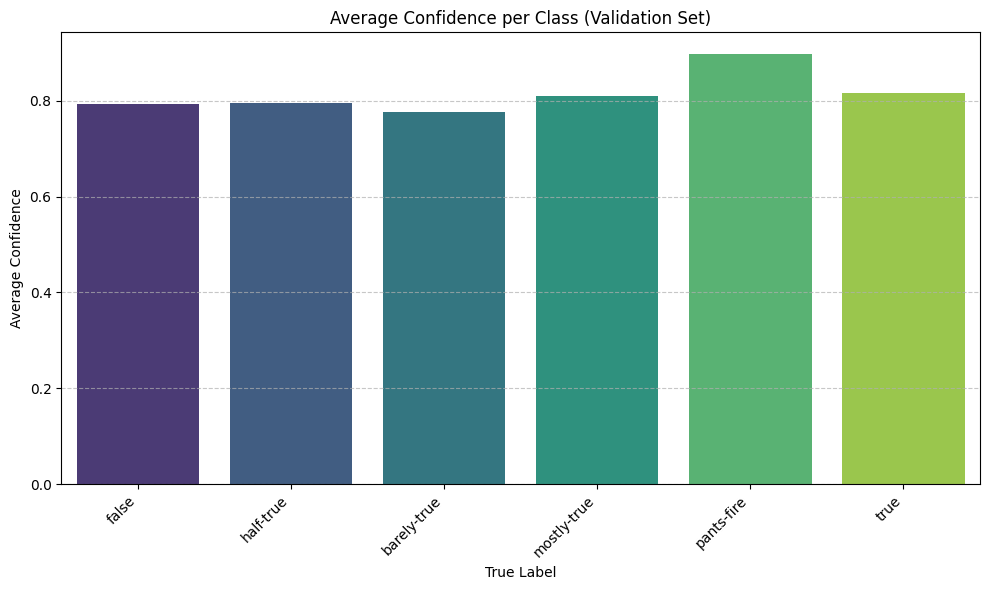

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='true_label', y='avg_conf', data=conf_stats_df, palette='viridis', hue='true_label', legend=False)
plt.title('Average Confidence per Class (Validation Set)')
plt.xlabel('True Label')
plt.ylabel('Average Confidence')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
print("\nTop Misclassifications (df_confusions):")
print("-------------------------------------")
print(df_confusions.head(10).to_markdown(index=False))


Top Misclassifications (df_confusions):
-------------------------------------
| true        | pred        |   count |
|:------------|:------------|--------:|
| barely-true | false       |      81 |
| pants-fire  | false       |      73 |
| barely-true | half-true   |      70 |
| true        | mostly-true |      47 |
| half-true   | mostly-true |      46 |
| mostly-true | half-true   |      45 |
| false       | barely-true |      42 |
| mostly-true | true        |      30 |
| false       | half-true   |      26 |
| half-true   | barely-true |      24 |
